# Phase II Plotting

This notebook follows the assignment Phase II task: vectorize the density-based artificial-compressibility solver. It keeps `main_solver.py` on the coupled SGS solver path, runs with `vectorize = True`, moves the standard solver plots into `Phase II Plots`, and saves vertical plus horizontal centerline profiles.

Working directory: /Users/windy/mae4100-courseproject2/start-code
Plot output directory: /Users/windy/mae4100-courseproject2/start-code/Phase II Plots
Running main_solver.py with solver_method = 'coupled', isgs = 1, vectorize = True
Iter.    Time (s)   dt (s)      Continuity    x-Momentum    y-Momentum
0   9.765625e-04   9.765625e-04   1.000000e+00   1.000000e+00   1.000000e+00


199   1.953125e-01   9.765625e-04   1.019877e-04   8.058646e-07   5.719258e-04
399   3.906250e-01   9.765625e-04   1.181315e-07   4.698803e-10   2.707759e-07


599   5.859375e-01   9.765625e-04   2.320590e-10   6.446902e-13   5.006747e-10
651 6.367188e-01 4.626943e-11 1.240270e-13 9.913961e-11
Elapsed time is  0.39118003845214844 sec
[0. 0. 0.] [0. 0. 0.] [0. 0. 0.]


Saved Phase II plots:
  Phase II Plots/horizontal_pressure_centerline_profile.png
  Phase II Plots/horizontal_velocity_centerline_profiles.png
  Phase II Plots/pcontour.png
  Phase II Plots/pressure_centerline_profile.png
  Phase II Plots/residual.png
  Phase II Plots/residualcomponent.png
  Phase II Plots/ucontour.png
  Phase II Plots/vcontour.png
  Phase II Plots/velocity_centerline_profiles.png


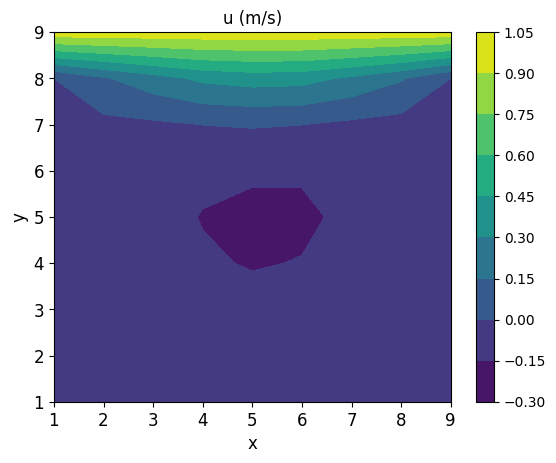

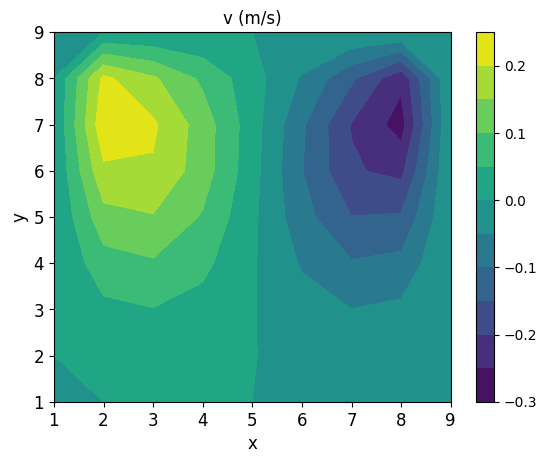

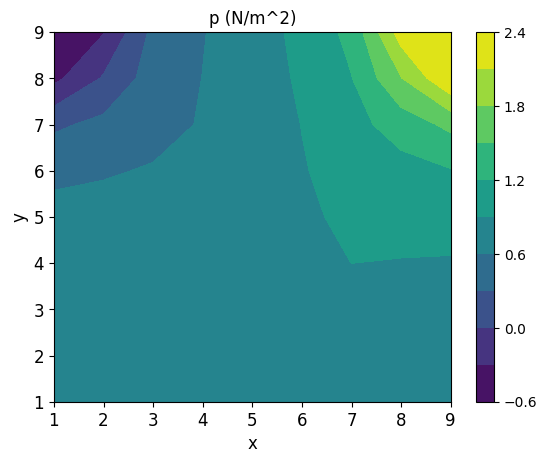

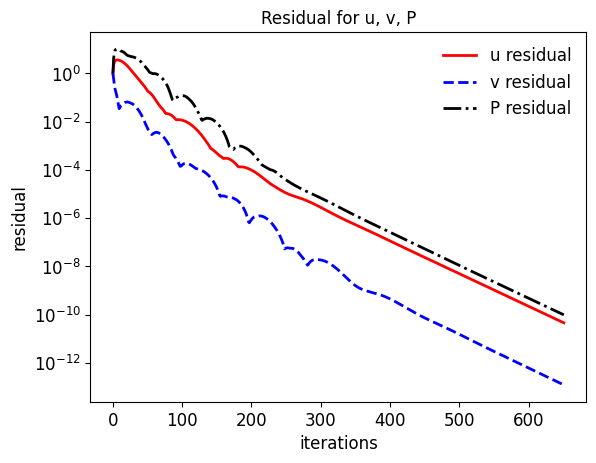

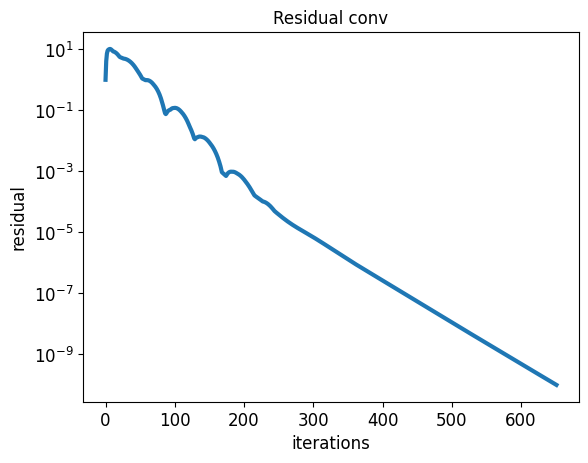

In [1]:
from pathlib import Path
import os
import shutil

import matplotlib.pyplot as plt
import numpy as np


def run_phase2_solver():
    """Run main_solver.py with assignment Phase II coupled vectorized settings."""
    solver_path = Path("main_solver.py")
    source = solver_path.read_text()

    replacements = {
        "vectorize = False":
            "vectorize = True",
    }

    for old, new in replacements.items():
        if old not in source:
            raise RuntimeError(f"Could not find expected setting in {solver_path}: {old}")
        source = source.replace(old, new, 1)

    namespace = {
        "__file__": str(solver_path.resolve()),
        "__name__": "__main__",
    }
    exec(compile(source, str(solver_path), "exec"), namespace)
    return namespace


def move_main_plots(plot_dir):
    main_plot_files = [
        "ucontour.png",
        "vcontour.png",
        "pcontour.png",
        "residualcomponent.png",
        "residual.png",
    ]

    for filename in main_plot_files:
        src = Path(filename)
        if src.exists():
            dst = plot_dir / filename
            if dst.exists():
                dst.unlink()
            shutil.move(str(src), str(dst))


def save_centerline_plots(plot_dir, u):
    fontsize = 12
    imax, jmax, _ = u.shape
    i_mid = (imax - 1) // 2
    j_mid = (jmax - 1) // 2
    x_profile = np.arange(1, imax + 1)
    y_profile = np.arange(1, jmax + 1)

    plt.figure(6)
    plt.plot(u[i_mid, :, 1], y_profile, "-r", linewidth=2, label="u velocity")
    plt.plot(u[i_mid, :, 2], y_profile, "--b", linewidth=2, label="v velocity")
    plt.xlabel("velocity (m/s)", fontsize=fontsize)
    plt.ylabel("y", fontsize=fontsize)
    plt.title("Phase II velocity profiles at x = 0.5L", fontsize=fontsize)
    plt.legend(loc="best", fontsize=fontsize, frameon=False)
    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.tight_layout()
    plt.savefig(plot_dir / "velocity_centerline_profiles.png", dpi=300)
    plt.close()

    plt.figure(7)
    plt.plot(u[i_mid, :, 0], y_profile, "-.k", linewidth=2, label="pressure")
    plt.xlabel("p (N/m^2)", fontsize=fontsize)
    plt.ylabel("y", fontsize=fontsize)
    plt.title("Phase II pressure profile at x = 0.5L", fontsize=fontsize)
    plt.legend(loc="best", fontsize=fontsize, frameon=False)
    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.tight_layout()
    plt.savefig(plot_dir / "pressure_centerline_profile.png", dpi=300)
    plt.close()

    plt.figure(8)
    plt.plot(x_profile, u[:, j_mid, 1], "-r", linewidth=2, label="u velocity")
    plt.plot(x_profile, u[:, j_mid, 2], "--b", linewidth=2, label="v velocity")
    plt.xlabel("x", fontsize=fontsize)
    plt.ylabel("velocity (m/s)", fontsize=fontsize)
    plt.title("Phase II velocity profiles at y = 0.5L", fontsize=fontsize)
    plt.legend(loc="best", fontsize=fontsize, frameon=False)
    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.tight_layout()
    plt.savefig(plot_dir / "horizontal_velocity_centerline_profiles.png", dpi=300)
    plt.close()

    plt.figure(9)
    plt.plot(x_profile, u[:, j_mid, 0], "-.k", linewidth=2, label="pressure")
    plt.xlabel("x", fontsize=fontsize)
    plt.ylabel("p (N/m^2)", fontsize=fontsize)
    plt.title("Phase II pressure profile at y = 0.5L", fontsize=fontsize)
    plt.legend(loc="best", fontsize=fontsize, frameon=False)
    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.tight_layout()
    plt.savefig(plot_dir / "horizontal_pressure_centerline_profile.png", dpi=300)
    plt.close()


def main():
    if Path.cwd().name != "start-code" and (Path.cwd() / "start-code").exists():
        os.chdir(Path.cwd() / "start-code")

    plot_dir = Path("Phase II Plots")
    plot_dir.mkdir(exist_ok=True)

    print(f"Working directory: {Path.cwd()}")
    print(f"Plot output directory: {plot_dir.resolve()}")
    print("Running main_solver.py with solver_method = 'coupled', isgs = 1, vectorize = True")

    solver_namespace = run_phase2_solver()
    move_main_plots(plot_dir)
    save_centerline_plots(plot_dir, solver_namespace["u"])

    print("Saved Phase II plots:")
    for path in sorted(plot_dir.glob("*.png")):
        print(f"  {path}")


main()